In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
data=r"C:\Users\sitar\Downloads\archive (3)"

In [2]:
import os
categories=os.listdir(data)
categories

['computer mouse',
 'keyboard I',
 'keys objects',
 'laptop',
 'magnifying glass',
 'phone',
 'router',
 'satellite dish device',
 'server rack',
 'USB stick']

In [ ]:
#Insights:The dataset contains multiple object categories such as computer mouse, keyboard, keys, satellite devices, etc.

In [3]:
len(categories)

10

In [4]:
img_path=[]
labels=[]
for category in categories:
    folder_path=os.path.join(data,category)
    for file in os.listdir(folder_path):
        file_path=os.path.join(folder_path,file)
        img_path.append(file_path)
        labels.append(category)


In [ ]:
#Insights:Images were collected and stored in different folders representing each class.
#Collected image paths from folders
#Created labels for each category

In [5]:
img_path[3]

'C:\\Users\\sitar\\Downloads\\archive (3)\\computer mouse\\img_859.jpg'

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(img_path,labels,test_size=0.2,random_state=42)

In [ ]:
#Split dataset into:
    #80% Training data
    #20% Testing data

In [7]:
len(x_train)

760

In [8]:
len(x_test)

190

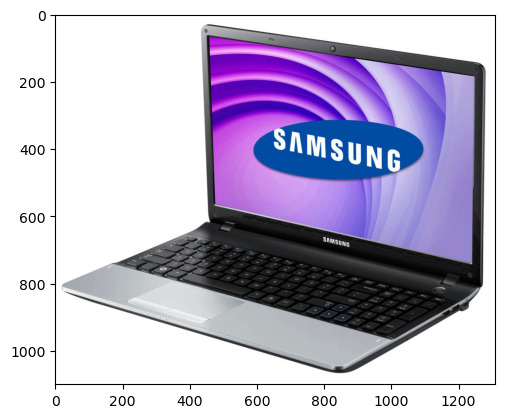

In [9]:
import PIL
from PIL import Image
img=Image.open(x_train[1])
plt.imshow(img)

# label mapping

In [10]:
label_map={}
for idx,category in enumerate(categories):
    label_map.update({category:idx})
label_map    

{'computer mouse': 0,
 'keyboard I': 1,
 'keys objects': 2,
 'laptop': 3,
 'magnifying glass': 4,
 'phone': 5,
 'router': 6,
 'satellite dish device': 7,
 'server rack': 8,
 'USB stick': 9}

In [ ]:
# Insights:Labels were created by mapping category names to numeric values using a label map.
#CNN models require numerical labels, so categorical labels were converted into numbers.

In [11]:
y_train1=[]
for label in y_train:
    y_train1.append(label_map[label])
y_train1[:5]

[9, 3, 5, 2, 1]

In [12]:
y_train1=np.array(y_train1)

In [13]:
y_train1.ndim

1

In [14]:
y_test1=[]
for y_t in y_test:
    y_test1.append(label_map[y_t])
y_test1[:5]

[2, 9, 7, 8, 9]

# preprocessing image

In [15]:
from keras.preprocessing.image import load_img,img_to_array
def preproc_img(img_path):
    img=load_img(img_path,target_size=(50,50))
    img_array=img_to_array(img)
    img_array=img_array/255.0
    return img_array

In [ ]:
#Resized images to 50 × 50 pixels
#Normalized pixel values (/255)

In [86]:
x_train1=[]
for x in x_train:
    x_train1.append(preproc_img(x))

In [17]:
x_train1=np.array(x_train1)
x_train1.ndim

4

In [18]:
x_train1.shape

(760, 50, 50, 3)

In [19]:
x_test1=[]
for x_t in x_test:
    x_test1.append(preproc_img(x_t))
x_test1[:1]

[array([[[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],
 
        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],
 
        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],
 
        ...,
 
        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],
 
        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]],
 
        [[1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.],
         ...,
         [1., 1., 1.],
         [1., 1., 1.],
         [1., 1., 1.]]], dtype=float32)]

In [20]:
x_test1=np.array(x_test1)

In [21]:
x_test1.ndim

4

In [22]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,AveragePooling2D

In [23]:
model=Sequential([
    Conv2D(32,(3,3),input_shape=(50,50,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3),activation='relu'),
    AveragePooling2D((2,2)),
    Flatten(),
    Dense(100,activation='relu'),
    Dropout(0.5),
    Dense(len(categories),activation='softmax')
])
    

C:\Users\sitar\ anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#The CNN learns edges → shapes → objects gradually.

In [24]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
#Sparse categorical crossentropy is used because labels are integer encoded.

In [60]:
model.fit(x_train1,y_train1,epochs=50,verbose=0)

In [61]:
model.evaluate(x_test1,np.array(y_test1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5947 - loss: 2.8696


[2.8695783615112305, 0.5947368144989014]

In [62]:
#Testing dataset measures how well the model generalizes to unseen images.

In [63]:
new_img=r"C:\Users\sitar\Downloads\download.jpg"
img_map=preproc_img(new_img)
img_map=np.array(img_map)

In [64]:
img_map.shape

(50, 50, 3)

In [65]:
img_ar=np.expand_dims(img_map,axis=0)

In [66]:
img_ar.ndim

4

In [67]:
categories

['computer mouse',
 'keyboard I',
 'keys objects',
 'laptop',
 'magnifying glass',
 'phone',
 'router',
 'satellite dish device',
 'server rack',
 'USB stick']

In [68]:
class_names=['computer mouse',
 'keyboard I',
 'keys objects',
 'laptop',
 'magnifying glass',
 'phone',
 'router',
 'satellite dish device',
 'server rack',
 'USB stick']


In [69]:
pre=model.predict(img_ar)
mod=np.argmax(pre)
mod

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


np.int64(3)

In [70]:
print("Predicted class:", class_names[mod])
print("Confidence:", np.max(pre))

Predicted class: laptop
Confidence: 0.99917006


In [71]:
#The model can predict real-world images with probability confidence.

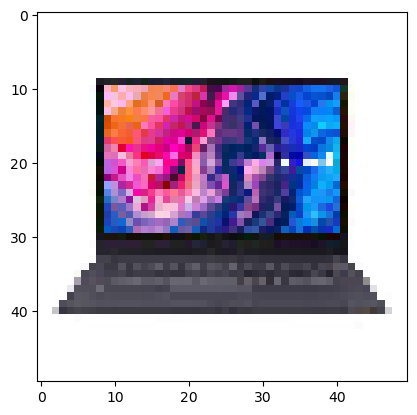

In [72]:
plt.imshow(img_map)

In [79]:
new_image=r"C:\Users\sitar\Downloads\download (2).jpg"
new_im=preproc_img(new_image)
img_mapp=np.array(new_im)
img_mapp.shape


(50, 50, 3)

In [80]:
img_arr=np.expand_dims(img_mapp,axis=0)

In [81]:
img_arr.ndim

4

In [82]:
pred=model.predict(img_arr)
mode=np.argmax(pred)
mode

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


np.int64(7)

In [83]:
print("Predicted class:", class_names[mode])
print("Confidence:", np.max(pred))

Predicted class: satellite dish device
Confidence: 0.7189232


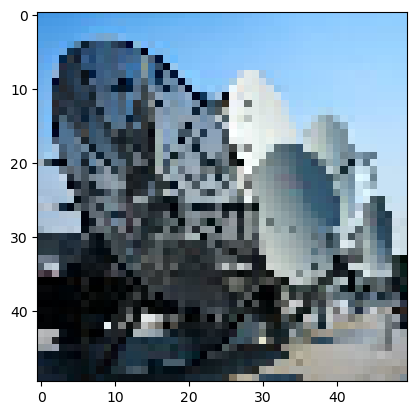

In [84]:
plt.imshow(img_mapp)

In [ ]:
# It predicts correct prediction when we are giving news images"

In [59]:
""" Conclusion : The CNN model automatically learns hierarchical visual features from images, starting from edges 
and textures to complex device shapes, enabling accurate multi-class classification."""

' Conclusion : The CNN model automatically learns hierarchical visual features from images, starting from edges \nand textures to complex device shapes, enabling accurate multi-class classification.'

In [ ]:
"""In this project, I built a CNN-based image classification model to identify different electronic devices such as laptops, keyboards, phones, and routers etc.
I first preprocessed the dataset by resizing images and normalizing pixel values.
Then I encoded the labels and split the data into training and testing sets.
I designed a convolutional neural network with convolution, pooling, dropout, and dense layers.
Finally, I trained the model and evaluated its performance on test images, where it successfully predicted the device category."""